# Temporal graph Transformer: mechanism, training, and evidence

This studybook turns notebook `07`'s bounded causal event tensors into a fitted attention model. It is written for an ML scientist who knows neural networks but may not know graph attention or temporal Transformers. We will derive the computation, connect every tensor to the code, inspect a real learned attention pattern, and compare five seeds on two development folds.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from graph_ml.baselines import (
    build_point_in_time_feature_frame,
    fit_point_in_time_encoder,
    transform_point_in_time_instruments,
)
from graph_ml.data import TEMPORAL_RELATIONS, build_temporal_event_sequences
from graph_ml.evaluation import (
    ExpandingWindowPlan,
    build_expanding_window_specs,
    build_horizon_label_availability,
    build_point_in_time_fold,
)
from graph_ml.training import TemporalTransformerTrainingConfig, fit_temporal_graph_transformer
from graph_ml.viz import (
    plot_backtest_pr_auc,
    plot_temporal_attention_schematic,
    plot_temporal_attention_weights,
    plot_training_history,
)

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
DATA = ROOT / 'data'

## 1. Attention is an aggregation rule inside a temporal graph model

It is tempting to describe this as ‘a Transformer on top of a GNN’. More precisely, the graph and timestamps first define the **legal candidate set**, and attention replaces a fixed mean or decay-weighted mean as the neighbour aggregator. An unrelated invoice is absent because there is no graph relation. An event at or after the query time is absent because the history builder requires $t_j<t_i$. Attention can only reweight the legal events that remain.

For current invoice $i$, the root projection creates a query $q_i$. Every retained historical event $j$ becomes a key $k_{ij}$ and value $v_{ij}$. A scaled dot product measures compatibility:

$$s_{ij}=q_i^T k_{ij}/\sqrt{d},\qquad \alpha_{ij}=\operatorname{softmax}_{j\in\mathcal{N}_{<t_i}(i)}(s_{ij}),\qquad m_i=\sum_j\alpha_{ij}v_{ij}.$$

The $\sqrt d$ scaling keeps score magnitudes controlled as hidden width grows. Softmax makes legal weights non-negative and sum to one. The message $m_i$ is therefore query-dependent: two current invoices sharing the same company history may emphasize different past events.

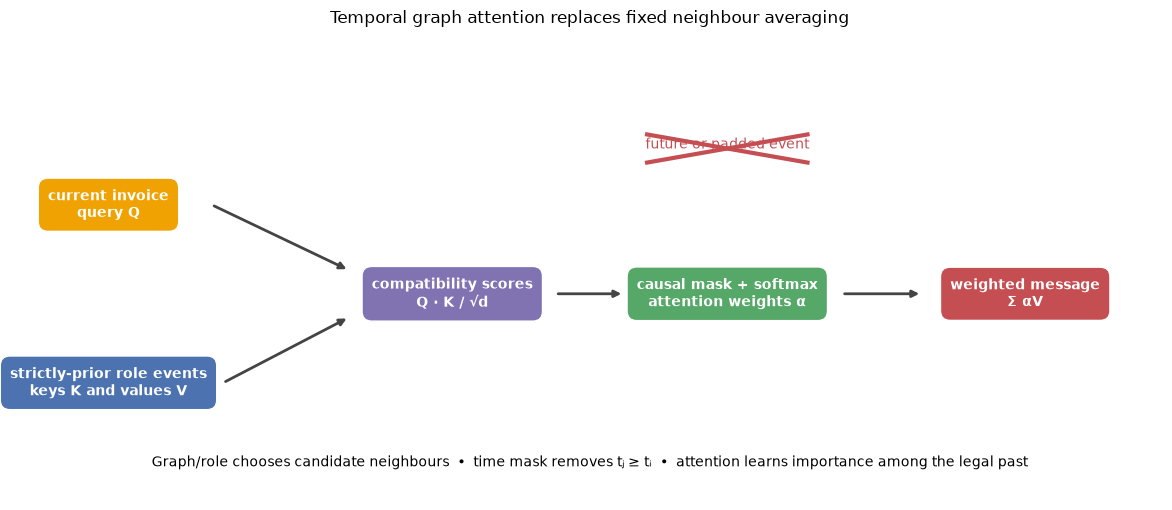

In [2]:
plot_temporal_attention_schematic()
plt.show()

## 2. What enters each key and value?

The historical event projection supplies content. A learned **relation embedding** identifies one of four paths: current seller through seller history, current seller through buyer history, current buyer through seller history, or current buyer through buyer history. A small neural network maps $\log(1+\Delta t)$ to a **continuous time encoding**. Log age compresses the long tail while keeping event order; unlike the previous model's fixed 180-day half-life, the mapping is learned. Content, time, and relation vectors are added before attention.

Four attention heads use separate learned projections. Heads are parallel feature subspaces, not four graph relations: a head might learn a recency pattern or an amount pattern across any relation. Their outputs are concatenated internally. Head count increases capacity but does not guarantee interpretable specialization. The public diagnostic averages weights across heads, so it is deliberately a coarse summary.

## 3. Masks, residual paths, and the empty-history case

Each query has a `[4, K]` validity mask. Padding positions are passed to multi-head attention as forbidden keys and receive exactly zero weight. Causality is enforced earlier while constructing the tensor, including exclusion of simultaneous events. Separating these duties makes both contracts directly testable.

A row with no legal history cannot be sent through ordinary softmax because every key would be masked, which can produce NaNs. The implementation detects such rows, returns an exactly zero message, and lets the root projection carry the current invoice. For other rows, a residual connection adds root and attention message, layer normalization controls scale, and a position-wise feed-forward network adds nonlinear capacity. ‘Position-wise’ means it transforms each query independently; it does not introduce new graph communication.

## 4. Training without crossing time

Each development origin has three stages. First, the feature encoder is fitted only on the expanding training mask. The model trains on that mask and validation PR-AUC chooses the epoch; class-weighted binary cross-entropy counters the rare positive class during optimization, while PR-AUC remains the selection metric. Second, a fresh encoder and fresh model are fitted on the legal train-plus-validation refit mask for exactly the selected number of epochs. Third, scores are read on the following development-test period.

Mini-batching does not remove graph history: the complete bounded history is materialized before batching, and a batch selects query rows plus their already-aligned legal event tensors. Outcomes are never event features. Five fixed seeds expose optimization variance. The final 2018 holdout remains untouched because these two earlier folds are the architecture-selection environment.

39,745 trainable parameters; selected epoch 5; validation PR-AUC 0.0087


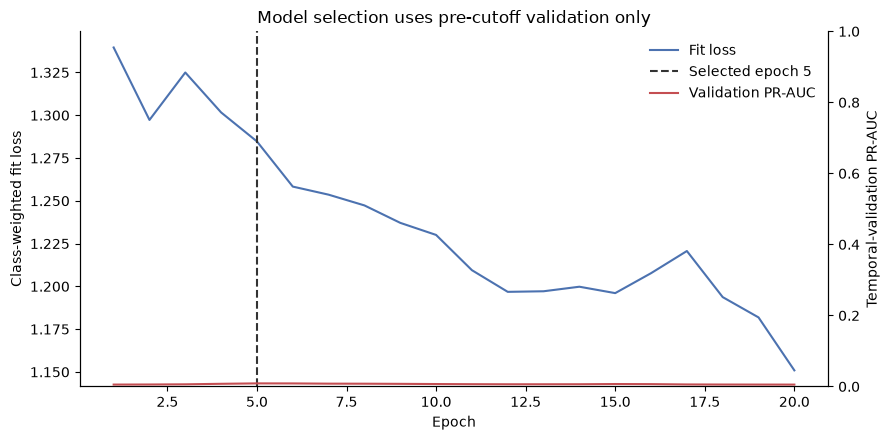

In [3]:
instruments = pd.read_parquet(DATA / '02_instrumentsdf_2.parquet')
availability = build_horizon_label_availability(
    instruments, target_column='is_pastdue90', horizon_days=90
)
specs = build_expanding_window_specs(ExpandingWindowPlan(
    first_train_end='2015-04-01', window_months=12, fold_count=2, final_holdout_start='2018-04-30'
))
fold = build_point_in_time_fold(instruments['invoice_date'], availability, specs[-1])
features = build_point_in_time_feature_frame(instruments)
config = TemporalTransformerTrainingConfig(seed=42)
run = fit_temporal_graph_transformer(instruments, features, availability, fold, config)
print(f'{run.parameter_count:,} trainable parameters; selected epoch {run.best_epoch}; validation PR-AUC {run.best_validation_pr_auc:.4f}')
plot_training_history(run.search_train_losses, run.search_validation_pr_aucs, best_epoch=run.best_epoch)
plt.show()

Training loss and ranking quality need not move together. Early stopping uses validation PR-AUC, not the lowest training loss. The selected epoch is then treated as a training-budget choice during refit; validation examples do not keep influencing gradient steps after that choice.

## 5. Inspect one real learned attention pattern

We reconstruct the exact refit encoder and K=8 histories, then select an anonymous test invoice with many legal slots. Each cell below reports averaged attention weight and event age. All weights across the four relations sum to one for this query; padding is zero. The view intentionally omits company identities and business values.

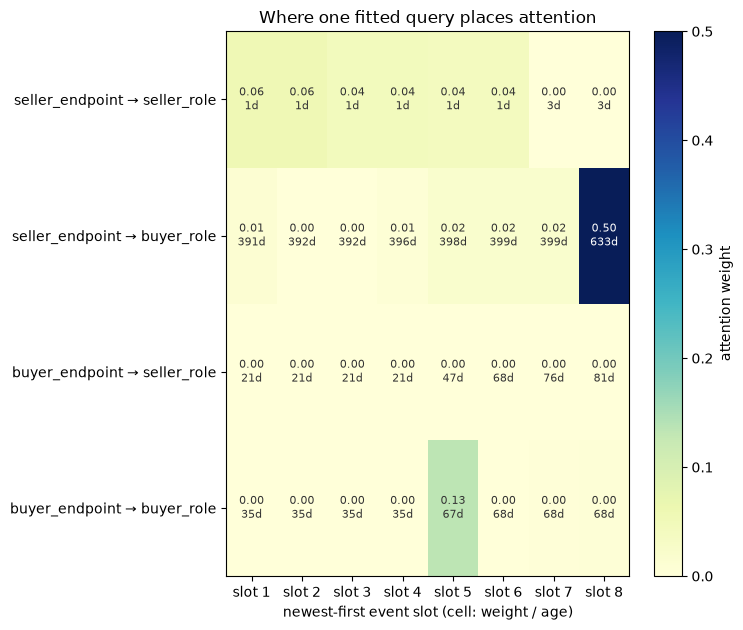

valid slots: 32; attention sum: 1.000000


In [4]:
encoder = fit_point_in_time_encoder(features, fold.refit_mask)
current, _ = transform_point_in_time_instruments(features, encoder)
sequences = build_temporal_event_sequences(instruments, current, max_events=config.max_events)
test_rows = np.flatnonzero(fold.test_mask)
inspection_row = test_rows[np.argmax(sequences.valid_mask[test_rows].sum(axis=(1, 2)))]
row = slice(inspection_row, inspection_row + 1)
run.model.eval()
with torch.no_grad():
    _, weights = run.model.attend(
        torch.from_numpy(current[row].astype(np.float32)),
        torch.from_numpy(sequences.values[row]),
        torch.from_numpy(sequences.age_days[row]),
        torch.from_numpy(sequences.valid_mask[row]),
    )
plot_temporal_attention_weights(
    weights[0].numpy(), sequences.age_days[inspection_row],
    sequences.valid_mask[inspection_row], TEMPORAL_RELATIONS,
)
plt.show()
print(f'valid slots: {sequences.valid_mask[inspection_row].sum()}; attention sum: {weights.sum().item():.6f}')

Attention weights answer a narrow question: **given this fitted model, query, candidate set, and representation, where did its aggregator place mass?** They are not causal effects, feature importance, or proof that an event caused predicted risk. Values are transformed before aggregation, heads can disagree, and correlated events can exchange weight. Useful diagnostics include checking padding weight, recency collapse, relation collapse, and stability across seeds; stronger explanation claims need perturbation or attribution studies.

## 6. Five-seed development evidence

The chart compares the deterministic causal LightGBM with five-seed root-only, fixed-decay temporal GNN, and temporal Transformer results. Bars are seed means; error bars are observed min–max ranges, not confidence intervals. The dashed prevalence is the random-ranking PR-AUC reference.

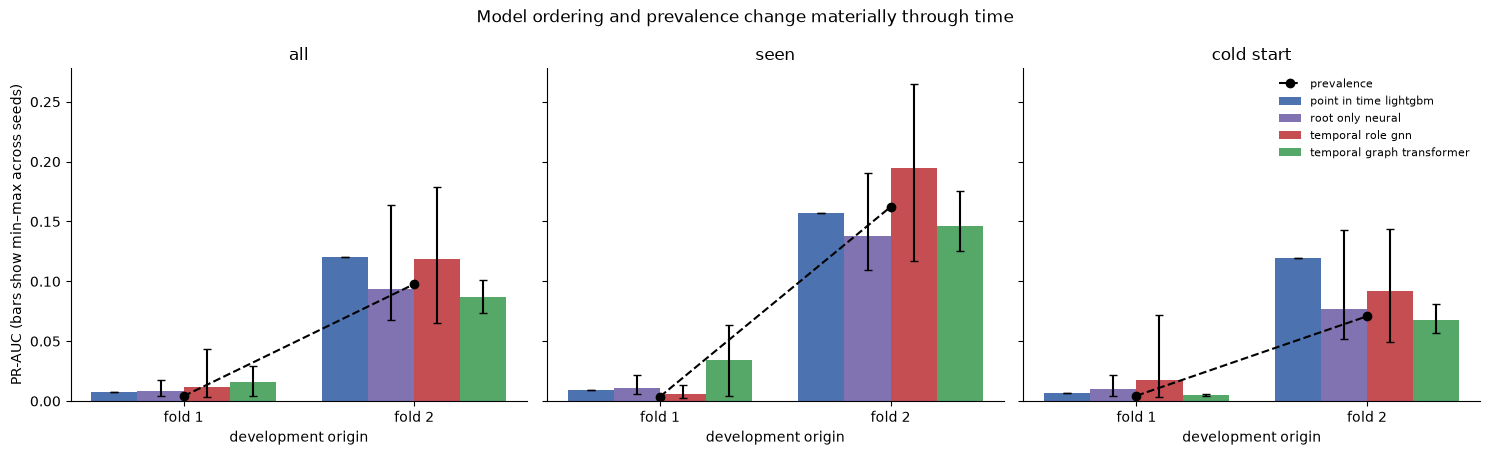

,fold,train_end,validation_end,test_end,model,cohort,run_count,mean_pr_auc,sample_std,minimum,maximum,sample_count,positive_count,prevalence
18,1,2015-04-01,2016-04-01,2017-04-01,temporal_graph_transformer,test_all,5,0.016,0.011,0.004,0.030,6604,27,0.41%
19,1,2015-04-01,2016-04-01,2017-04-01,temporal_graph_transformer,test_seen,5,0.034,0.028,0.005,0.064,3245,12,0.37%
20,1,2015-04-01,2016-04-01,2017-04-01,temporal_graph_transformer,test_cold_start,5,0.005,0.001,0.004,0.006,3359,15,0.45%
21,2,2016-04-01,2017-04-01,2018-04-01,temporal_graph_transformer,test_all,5,0.087,0.011,0.074,0.101,21556,2106,9.77%
22,2,2016-04-01,2017-04-01,2018-04-01,temporal_graph_transformer,test_seen,5,0.146,0.018,0.125,0.175,6337,1028,16.22%
23,2,2016-04-01,2017-04-01,2018-04-01,temporal_graph_transformer,test_cold_start,5,0.067,0.010,0.057,0.081,15219,1078,7.08%


cohort     test_all  test_cold_start  test_seen
fold seed                                      
1    7        0.030            0.005      0.064
     19       0.006            0.006      0.007
     42       0.022            0.004      0.061
     73       0.004            0.004      0.005
     101      0.018            0.005      0.034
2    7        0.074            0.057      0.125
     19       0.101            0.081      0.175
     42       0.092            0.072      0.145
     73       0.087            0.067      0.140
     101      0.079            0.060      0.145

In [5]:
summary = pd.read_csv(ROOT / 'results' / 'temporal_backtest_p90_summary.csv')
transformer_runs = pd.read_csv(ROOT / 'results' / 'temporal_transformer_backtest_p90_metrics.csv')
plot_backtest_pr_auc(summary)
plt.show()
display(summary.loc[summary['model'] == 'temporal_graph_transformer'].style.format({
    'mean_pr_auc': '{:.3f}', 'sample_std': '{:.3f}', 'minimum': '{:.3f}',
    'maximum': '{:.3f}', 'prevalence': '{:.2%}',
}))
display(transformer_runs.pivot_table(index=['fold', 'seed'], columns='cohort', values='pr_auc').round(3))

The Transformer is useful evidence, but not the new winner. In sparse fold 1 it improves the overall mean over the fixed-decay temporal GNN (0.016 versus 0.012) and is much stronger for seen companies (0.034 versus 0.006), with substantial seed spread. Its cold-start mean is only 0.005, close to prevalence, because attention has little or no history to select. In denser fold 2 it trails both LightGBM and the temporal GNN overall (0.087 versus 0.120 and 0.119) and on seen companies (0.146 versus 0.157 and 0.194).

That pattern rejects the broad claim that learned attention is automatically better than a fixed temporal aggregator. The architecture has more selective capacity, but only two development origins and high regime shift. The next improvement should be a validation-only ablation, not final-holdout evaluation: compare learned time encoding with explicit decay, test smaller capacity/stronger regularization, and improve the root fallback or fusion gate. K and head count should change only under the same rolling protocol.

## Takeaways

1. Graph structure selects possible neighbours; strict event time selects legal neighbours; attention learns query-dependent weights among them.
2. Relation and continuous-time encodings tell attention what path an event used and how old it is.
3. Padding, simultaneous-event exclusion, and exact empty-history fallback are correctness properties, not optional tuning details.
4. Attention weights are model diagnostics, not causal explanations.
5. The five-seed backtest does not justify promoting this Transformer yet: it helps one sparse seen-company regime but loses in the denser fold and cannot solve cold start.